In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv('../Data/cells_concat_filtered.csv')

In [26]:
from itertools import combinations

def plot_violin_by_window(df, column='Ef_cell', color='black', figsize=(12, 6), top=0.5, bot=0,
                          title=None, ylabel=None, n=30):
    """
    Plot violin plots for WT constructs grouped by window, with overlaid violins per well.
    Lines connect the mean of medians between consecutive windows.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data with 'construct' column in format ###-###_X###Y
    column : str, default='Ef_cell'
        Column name to plot on y-axis
    color : str, default='black'
        Color for all violins
    figsize : tuple, default=(12, 6)
        Figure size (width, height)
    top : float, default=0.5
        Top limit of y-axis
    bot : float, default=0
        Bottom limit of y-axis
    title : str or None
        Plot title
    ylabel : str or None
        Y-axis label. If None, uses column name
    n : int, default=30
        Minimum number of data points required per well to include it
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    # Extract window and mutation information
    df_copy = df.copy()
    df_copy['window'] = df_copy['construct'].str.extract(r'^(\d+-\d+)')[0]
    df_copy['mutation'] = df_copy['construct'].str.extract(r'_(.+)$')[0]
    
    # Filter for WT constructs only
    wt_df = df_copy[df_copy['mutation'] == 'WT'].copy()
    
    # Remove NaN values from the column of interest
    wt_df = wt_df[wt_df[column].notna()]
    
    # Get unique windows and sort them by starting position
    windows = wt_df['window'].unique()
    # Sort by the first number in the window range
    windows_sorted = sorted(windows, key=lambda x: int(x.split('-')[0]))
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store positions and mean of medians for connecting lines
    positions = np.arange(len(windows_sorted))
    mean_values = []
    
    # Plot violins for each window
    for i, window in enumerate(windows_sorted):
        window_data = wt_df[wt_df['window'] == window]
        
        # Get unique wells for this window
        wells = window_data['well'].unique()
        
        # Store well medians
        well_medians = []
        
        # Plot each well as a separate violin, overlaid
        for well in wells:
            well_data = window_data[window_data['well'] == well][column].values
            
            if len(well_data) >= n:  # Filter by minimum n
                well_medians.append(np.median(well_data))
                
                parts = ax.violinplot([well_data], positions=[i], 
                                     widths=0.6, showmeans=False, 
                                     showmedians=False, showextrema=False)
                
                for pc in parts['bodies']:
                    pc.set_alpha(0.3)
                    pc.set_facecolor('none')
                    pc.set_edgecolor(color)
        
        # Calculate mean of medians and std of medians
        if len(well_medians) > 0:
            mean_of_medians = np.mean(well_medians)
            std_of_medians = np.std(well_medians, ddof=1) if len(well_medians) > 1 else 0
            
            # Store mean value for connecting line
            mean_values.append(mean_of_medians)
            
            # Plot mean of medians as a point with error bar
            ax.errorbar(i, mean_of_medians, yerr=std_of_medians, 
                       fmt='o', color='black', markersize=8, 
                       linewidth=2, capsize=5, capthick=2, zorder=10)
        else:
            mean_values.append(np.nan)
    
    # Draw lines connecting mean of medians between consecutive windows
    valid_indices = [i for i, val in enumerate(mean_values) if not np.isnan(val)]
    if len(valid_indices) > 1:
        for i in range(len(valid_indices) - 1):
            idx1, idx2 = valid_indices[i], valid_indices[i + 1]
            ax.plot([idx1, idx2], [mean_values[idx1], mean_values[idx2]], 
                   color='grey', linestyle='-', linewidth=1.5, alpha=0.6, zorder=5)
    
    # Set y-axis limits
    ax.set_ylim(bottom=bot, top=top)
    
    # Set y-axis ticks at multiples of 0.1
    y_ticks = np.arange(np.ceil(bot * 10) / 10, top + 0.01, 0.1)
    ax.set_yticks(y_ticks)
    
    # Set x-axis labels to window names
    ax.set_xticks(positions)
    ax.set_xticklabels(windows_sorted, rotation=45, ha='right')
    
    # Set x-axis limits
    ax.set_xlim(-0.5, len(windows_sorted) - 0.5)
    
    # Labels
    ax.set_ylabel(ylabel if ylabel else column, fontsize=14)
    if title:
        ax.set_title(title, fontsize=16)
    
    plt.tight_layout()
    
    return fig, ax

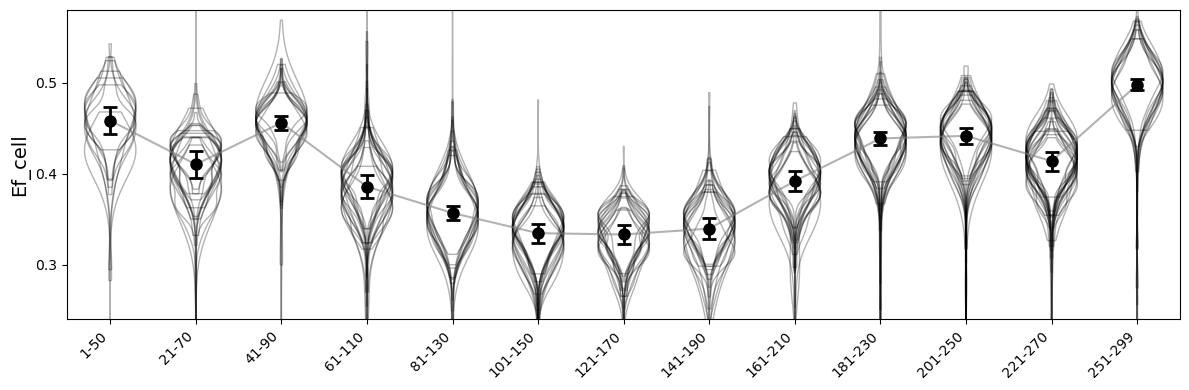

In [40]:
# Call the function to create the plot
fig, ax = plot_violin_by_window(df, column='Ef_cell', color='black', 
                                 figsize=(12, 4), top=0.58, bot=0.24,
                                 ylabel='Ef_cell', n=30)
plt.show()

In [41]:
dfA = pd.read_csv('../Data/StallerActivities.csv')

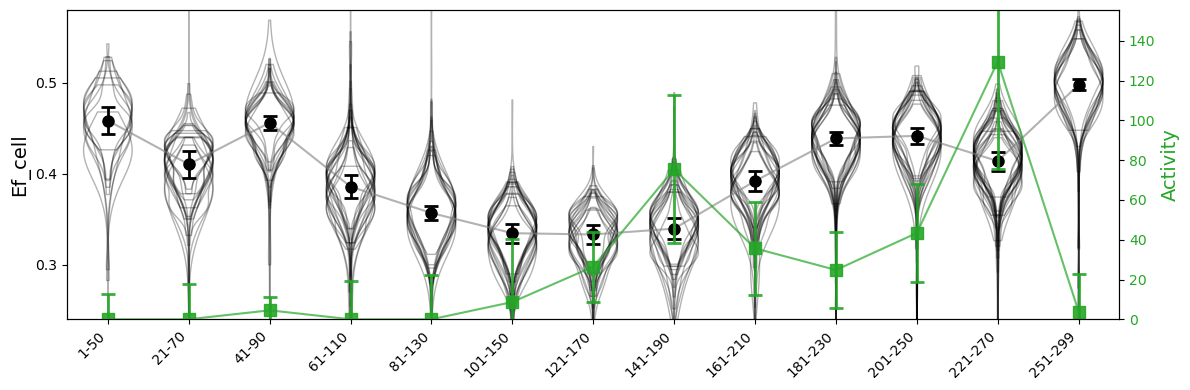

In [53]:
# Call the function to create the plot
fig, ax = plot_violin_by_window(df, column='Ef_cell', color='black', 
                                 figsize=(12, 4), top=0.58, bot=0.24,
                                 ylabel='Ef_cell', n=30)

# Create second y-axis for activity data
ax2 = ax.twinx()

# Sort dfA by first component of Tile (###-###)
dfA_sorted = dfA.copy()
dfA_sorted['tile_start'] = dfA_sorted['Tile'].str.extract(r'^(\d+)')[0].astype(int)
dfA_sorted = dfA_sorted.sort_values('tile_start')

# Get positions matching the windows
positions = np.arange(len(dfA_sorted))

# Plot activity data with error bars on second axis
ax2.errorbar(positions, dfA_sorted['Activity_Mean_MSS18'], 
             yerr=dfA_sorted['Activity_std_MSS18'],
             fmt='s', color="#25A627", markersize=8, 
             linewidth=2, capsize=5, capthick=2, 
             alpha=.9, label='Activity')

# Connect activity points with line
ax2.plot(positions, dfA_sorted['Activity_Mean_MSS18'], 
         color="#25A627", linestyle='-', linewidth=1.5, alpha=0.7, zorder=5)

# Set labels for second axis
ax2.set_ylabel('Activity', fontsize=14, color="#25A627")
ax2.tick_params(axis='y', labelcolor="#25A627")

# Set y-axis limits for activity (adjust as needed)
ax2.set_ylim(bottom=0, top=dfA_sorted['Activity_Mean_MSS18'].max() * 1.2)

plt.tight_layout()
plt.show()